In [114]:
# --- IMPORT STATEMENTS ---

# Standard library
import os
import numpy as np

# Third-party libraries
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Astropy (astronomy-specific)
from astropy.io import fits
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales

# Reproject (map reprojection & mosaicking)
from reproject import reproject_interp
from reproject.mosaicking import find_optimal_celestial_wcs, reproject_and_coadd


In [115]:
# --- GLOBAL VARIABLES ---

LINUX_DIRECTORY = "/home/aimee/mphys" # Aimee
GDIGS_MAPS_DIR = f"{LINUX_DIRECTORY}/data/GDIGS_moment0" # Aimee
MOSAIC_SAVEDIR = f'{LINUX_DIRECTORY}/data/GDIGS_mosaic' # Aimee
# LINUX_DIRECTORY = '/home/u20482jg/MPHYS_Project_Local' # Joe
# GDIGS_MAPS_DIR = f"{LINUX_DIRECTORY}/data/GDIGS_Mosaics/moment0" # Joe
# MOSAIC_SAVEDIR = f'{LINUX_DIRECTORY}/data/GDIGS_Mosaics' #Joe

STEP = 0.0083333333333333 # original GDIGS pixel size in degrees (1/2 arcmin) (exact from header)

GDIGS_MAPS = {
    "GDIGS G002.50":"GDIGS_G002.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G007.50":"GDIGS_G007.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G012.50":"GDIGS_G012.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G017.50":"GDIGS_G017.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G022.50":"GDIGS_G022.50+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G027.25":"GDIGS_G027.25+00.00_halpha_2pol_average_moment0.fits",
    "GDIGS G030.80":"GDIGS_G030.80+00.00_halpha_2pol_average_moment0.fits", 
    # "GDIGS G037.50":"GDIGS_G037.50+00.00_halpha_2pol_average_moment0.fits", # small square on its own
    # "GDIGS G037.50":"GDIGS_G037.50+01.00_halpha_2pol_average_moment0.fits", # small square on its own
    # "GDIGS G043.00":"GDIGS_G043.00+00.00_halpha_2pol_average_moment0.fits", # small square on its own
    # "GDIGS G173.60":"GDIGS_G173.60+02.70_halpha_2pol_average_moment0.fits", # ValueError: Input WCS is not 2-dimensional
    "GDIGS G357.75":"GDIGS_G357.75+00.00_halpha_2pol_average_moment0.fits",
    }
GDIGS_KEYS = list(GDIGS_MAPS.keys())

In [116]:
# --- FUNCTION DEFINITIONS ---

In [117]:
def plot_map(data, wcs, title='Title'):
    
    plt.figure(figsize=(12, 3), dpi=300)
    ax = plt.subplot(projection=wcs)

    levels = [2, 4, 8, 16, 32]
    contour_colors = plt.cm.Greys(np.linspace(0.3, 0.9, len(levels)))  # shades from light to dark gray
    for lev, col in zip(levels, contour_colors):
        ax.contour(data, levels=[lev], colors=[col], linewidths=0.5)

    im = ax.imshow(data, origin='lower', cmap='inferno', vmin=-2, vmax=16)
    plt.title(title, fontsize=14)
    plt.xlabel(r'$\ell$', fontsize=14)
    plt.ylabel(r'$b$', fontsize=14)
    plt.tick_params(labelsize=12)
    plt.colorbar(im, ax=ax, label='K')
    plt.tight_layout()
    plt.show()

In [118]:
def reproject_data(data, wcs, shape_out, pixel_scale_deg): # don't use - rebin manually instead
    
    # Get the center of the original image (mosaic_wcs)
    center_pix = np.array(shape_out) / 2
    center_lon, center_lat = wcs.pixel_to_world_values(center_pix[1], center_pix[0]) 

    # Determine angular size of the original image (in degrees)
    orig_scales = proj_plane_pixel_scales(wcs)  # degrees/pixel in x and y
    size_deg_x = orig_scales[0] * shape_out[1]
    size_deg_y = orig_scales[1] * shape_out[0]

    # Compute new shape in pixels for the same area with 1 arcmin/pixel
    new_shape_x = int(np.ceil(size_deg_x / pixel_scale_deg))
    new_shape_y = int(np.ceil(size_deg_y / pixel_scale_deg))
    new_shape = (new_shape_y, new_shape_x)

    # Create a new WCS
    new_wcs = WCS(naxis=2)
    new_wcs.wcs.crval = [center_lon, center_lat]              # center of the image in degrees
    new_wcs.wcs.crpix = [new_shape[1] / 2, new_shape[0] / 2]  # center pixel for new shape
    new_wcs.wcs.ctype = list(wcs.wcs.ctype)           # keep original projection
    new_wcs.wcs.cdelt = np.array([-pixel_scale_deg, pixel_scale_deg])  # pixel scale in degrees

    # Reproject the mosaic to the new WCS
    data_reprojected, footprint = reproject_interp(
        (data, wcs),
        new_wcs,
        shape_out=new_shape
    )

    # Convert the WCS to a FITS header
    new_header = new_wcs.to_header()

    return data_reprojected, new_wcs, new_header

In [119]:
def rebin_data(data, factor):
    n_rows, n_cols = data.shape
    # print(f"Original shape: {data.shape}")

    # Crop rows and columns if not divisible by factor
    if n_rows % factor != 0:
        new_n_rows = (n_rows // factor) * factor
        data = data[:new_n_rows, :]
        # print(f"Adjusted rows to: {new_n_rows}")
    if n_cols % factor != 0:
        new_n_cols = (n_cols // factor) * factor
        data = data[:, :new_n_cols]
        # print(f"Adjusted columns to: {new_n_cols}")

    # Reshape and average in blocks of factor x factor
    reshaped_data = data.reshape(data.shape[0] // factor, factor, data.shape[1] // factor, factor)
    rebinned_data = reshaped_data.mean(axis=(1, 3))  # If any pixel in block is nan, whole block is nan (good)
    # print(f"Re-shaped data to: {rebinned_data.shape}")
    
    return rebinned_data


def rebin_mask(mask, factor):
    
    mask = np.where(mask == True, np.nan, 0) # convert boolean (masked = True) to masked = Nan
    mask = rebin_data(mask, factor) # rebin_data handles nans correctly
    mask = np.isnan(mask) # convert back to boolean mask

    return mask


def rebin_GDIGS(data, wcs, header, factor):
    
    # l_min = L_BOUNDS[0]
    # l_max = L_BOUNDS[1]
    # b_min = B_BOUNDS[0]
    # b_max = B_BOUNDS[1]
    step =  STEP # pixel size in degrees

    data = rebin_data(data, factor)

    ny, nx = data.shape
    cy, cx = ny // 2, nx // 2
    # print(cy, cx)   

    header = wcs.to_header()
    
    new_wcs = wcs.copy()
    # Indices for cutout - HARD CODED
    new_wcs.wcs.crpix[0] = wcs.wcs.crpix[0] / factor
    new_wcs.wcs.crpix[1] = wcs.wcs.crpix[1] / factor
    new_wcs.wcs.cdelt[0] = -step * factor
    new_wcs.wcs.cdelt[1] = step * factor
    new_wcs.wcs.crval[0] = wcs.wcs.crval[0]
    new_wcs.wcs.crval[1] = wcs.wcs.crval[1]

    header_new = new_wcs.to_header()
    
    # header_new['CRPIX1'] = 1084
    # header_new['CRPIX2'] = 95
    # header_new['CDELT1'] = -step * factor
    # header_new['CDELT1'] = step * factor
    # header_new['CRVAL1'] = 14.791860982537
    # header_new['CRVAL2'] = 0
    # header_new['NAXIS1'] = data.shape[1]
    # header_new['NAXIS2'] = data.shape[0]

    # wcs_new = WCS(header_new)

    return data, new_wcs, header_new


Original wcs: WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-TAN' 'GLAT-TAN' 
CRVAL : 14.791860982536837 0.0 
CRPIX : 2168.926896607652 189.8076743990724 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00833333333333333 0.00833333333333333 
NAXIS : 0  0


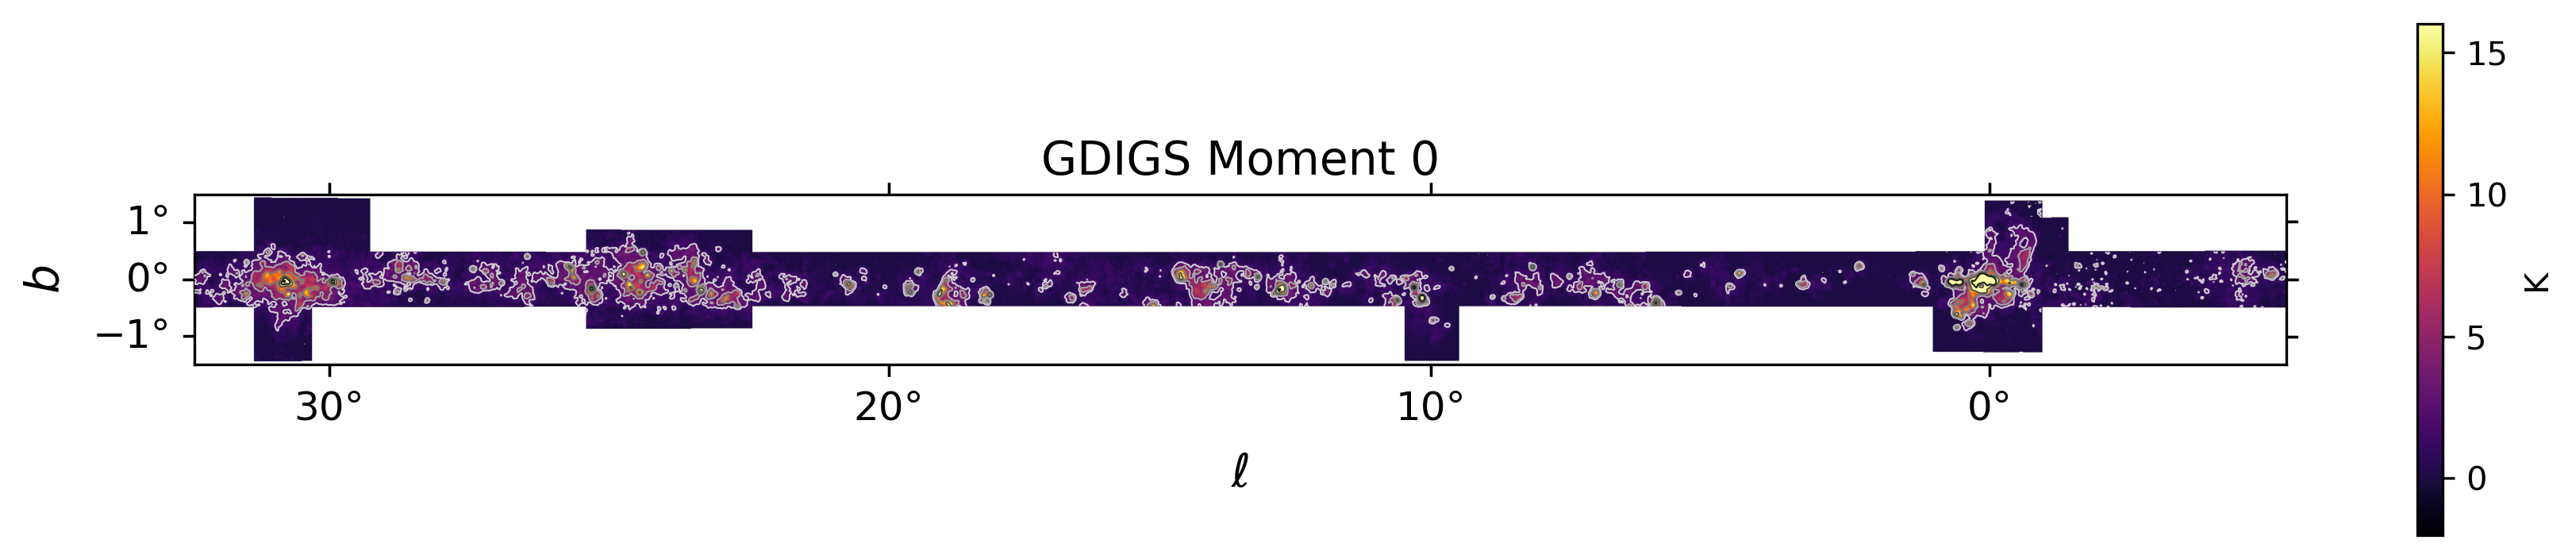

Rebinned wcs: WCS Keywords

Number of WCS axes: 2
CTYPE : 'GLON-TAN' 'GLAT-TAN' 
CRVAL : 14.791860982536837 0.0 
CRPIX : 1084.463448303826 94.9038371995362 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0166666666666666 0.0166666666666666 
NAXIS : 0  0


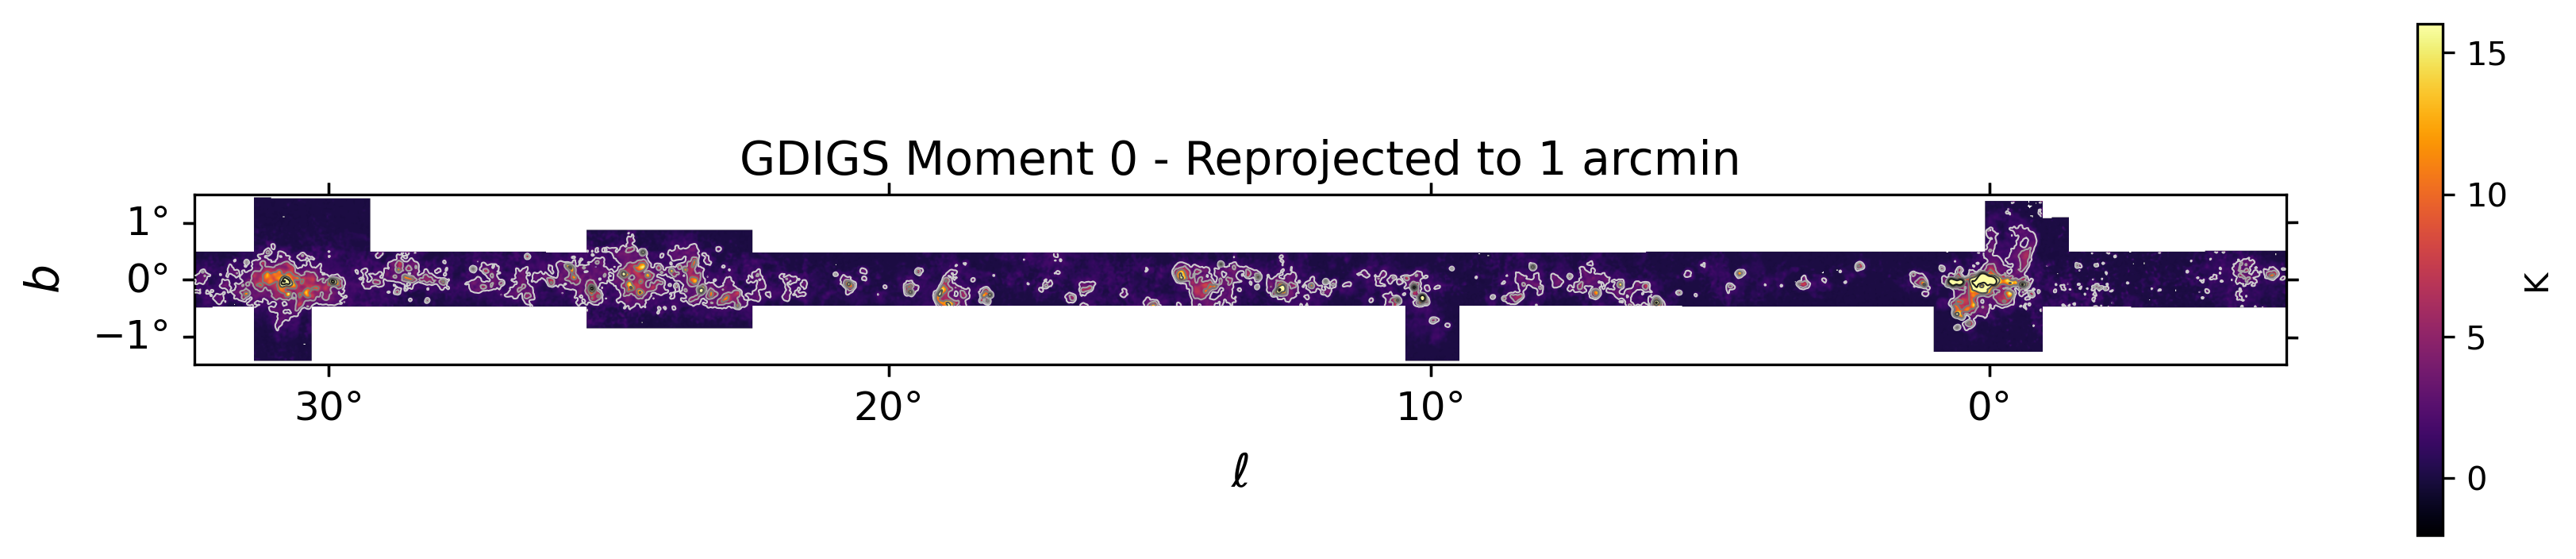

In [120]:
# --- MAIN CODE ---
# modified from gah_notebooks/gp_plots.ipynb
paths = []
for key in GDIGS_KEYS:
    paths.append(f"{GDIGS_MAPS_DIR}/{GDIGS_MAPS[key]}")

GDIGS_rawfits = [fits.open(path)[0] for path in paths]

mosaics = [(rawfit.data, rawfit.header) for rawfit in GDIGS_rawfits]

mosaic_wcs, shape_out = find_optimal_celestial_wcs(mosaics)

print(f'\nOriginal wcs: {mosaic_wcs}') # DEBUG

mosaic, _mosaic_ftprint = reproject_and_coadd(
    mosaics,
    output_projection = mosaic_wcs,
    shape_out = shape_out,
    reproject_function = reproject_interp,
    combine_function = "mean"
    )

# prevents area outside mosaic from being plotted
mosaic[mosaic == 0.0] = np.nan

# NO REPROJECTING
header = mosaic_wcs.to_header()
hdu = fits.PrimaryHDU(data=mosaic, header=header)
hdu.header['BUNIT'] = 'K'

hdu.writeto(f'{MOSAIC_SAVEDIR}/gdigs_moment0_mosaic.fits', overwrite=True)
plot_map(mosaic, mosaic_wcs, title='GDIGS Moment 0')

# REBINNING

factor = 2
mosaic_reprojected, mosaic_reprojected_wcs, mosaic_reprojected_header = rebin_GDIGS(mosaic, mosaic_wcs, header, factor)
print(f'Rebinned wcs: {mosaic_reprojected_wcs}')
plot_map(mosaic_reprojected, mosaic_reprojected_wcs, title='GDIGS Moment 0 - Reprojected to 1 arcmin')

hdu = fits.PrimaryHDU(data=mosaic_reprojected, header=mosaic_reprojected_header)
hdu.header['BUNIT'] = 'K'
hdu.header['NAXIS1'] = mosaic_reprojected.shape[1]
hdu.header['NAXIS2'] = mosaic_reprojected.shape[0]
hdu.writeto(f'{MOSAIC_SAVEDIR}/gdigs_moment0_mosaic_1amin.fits', overwrite=True)

